## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Load Data

In [2]:
df = pd.read_csv(r"C:\Users\Naz\Desktop\Naz\jobs\inv\Code\fabenode-data-report\data\raw\user_48_feb02_14_full_hrv.csv")

## 3. Datetime Preparation

In [3]:
df["start_time"] = pd.to_datetime(df["start_time"])
df["finish_time"] = pd.to_datetime(df["finish_time"])

## 4. Define Clean Dataset

In [11]:
clean_df = df[df["message"] == "SUCCESS"].copy()
clean_df.shape

(735, 56)

## 5. Stress and Fatigue Availability

In [13]:
clean_df[[
    "stress_score",
    "stress_level",
    "fatique_score",
    "fatique_level"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
stress_score,735.0,4.556463,2.658442,0.0,3.0,5.0,7.0,8.0
fatique_score,735.0,2.838095,1.390770,0.0,2.0,3.0,4.0,5.0


In [14]:
clean_df["stress_level"].value_counts()

stress_level
Moderate Stress    338
High Stress        221
Low Stress         176
Name: count, dtype: int64

In [15]:
clean_df["fatique_level"].value_counts()

fatique_level
Moderate Fatigue    490
Low Fatigue         245
Name: count, dtype: int64

## 6. Relationship Between Stress and HRV

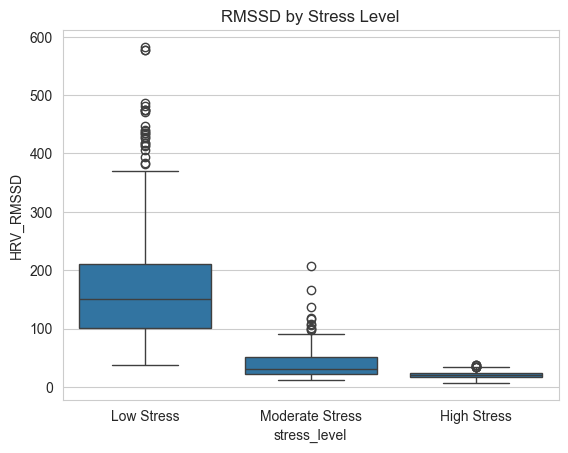

In [16]:
sns.boxplot(
    x="stress_level",
    y="HRV_RMSSD",
    data=clean_df
)

plt.title("RMSSD by Stress Level")
plt.show()

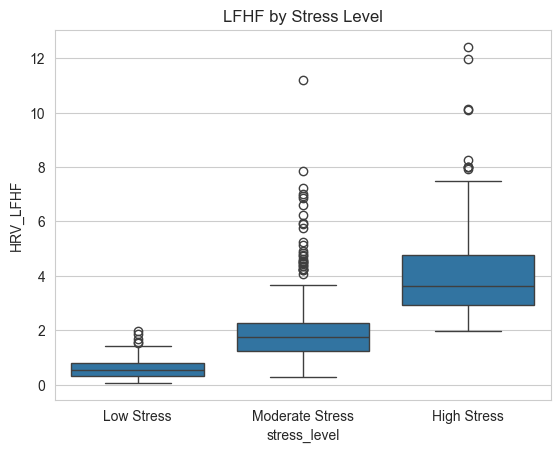

In [17]:
sns.boxplot(
    x="stress_level",
    y="HRV_LFHF",
    data=clean_df
)

plt.title("LFHF by Stress Level")
plt.show()

## 7. Stress Score vs HRV (numeric relationship)

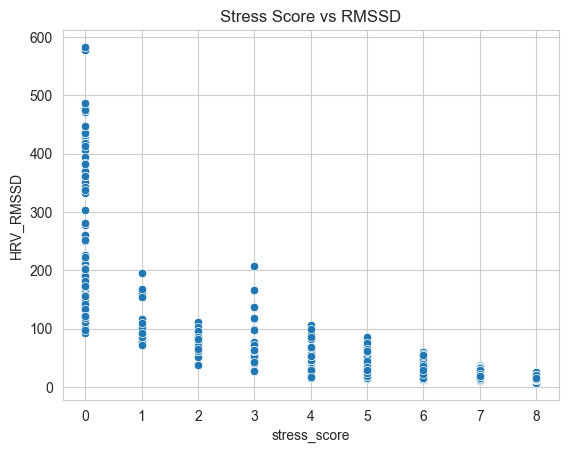

In [18]:
sns.scatterplot(
    x="stress_score",
    y="HRV_RMSSD",
    data=clean_df
)

plt.title("Stress Score vs RMSSD")
plt.show()

## 8. Fatigue vs HRV

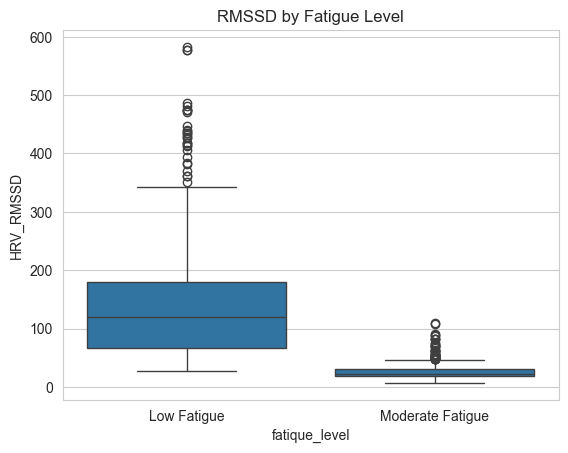

In [19]:
sns.boxplot(
    x="fatique_level",
    y="HRV_RMSSD",
    data=clean_df
)

plt.title("RMSSD by Fatigue Level")
plt.show()